## Inductive Conformal Prediction

[gentle intro](https://arxiv.org/abs/2107.07511)

Conformal Prediction (CP) is a method that aims to estimate model uncertainty in order to provide predictions that

In [71]:
import pandas as pd
from morgoth.conformal_prediction import get_pred_score_true_class, eval_classification_true_class
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from rdkit.Chem import Descriptors, MolFromSmiles
import matplotlib.pyplot as plt
import math

In [65]:
smiles_df = pd.read_csv('../data/compounds_with_smiles.csv', sep = '\t')
smiles_df.head()

,compound,smiles,inchi,inchikey
0,DTXSID9046499,CCOC(=O)COc1ccc2c(C)c(CCN(CC)CC)c(=O)oc2c1Cl.Cl,InChI=1S/C20H26ClNO5.ClH/c1-5-22(6-2)11-10-15-...,CCCZJRFQJNGCCU-UHFFFAOYSA-N
1,DTXSID3049386,CCC[N+]1(C)CCCCC1.F[P-](F)(F)(F)(F)F,InChI=1S/C9H20N.F6P/c1-3-7-10(2)8-5-4-6-9-10;1...,CDBFWKDOZHJELY-UHFFFAOYSA-N
2,DTXSID1048625,C[C@H](CSC(=O)c1ccccc1)C(=O)N1C[C@@H](Sc2ccccc...,InChI=1S/2C22H23NO4S2.Ca/c2*1-15(14-28-22(27)1...,NSYUKKYYVFVMST-LETVYOFWSA-L
3,DTXSID3045568,CCN(CC)Cc1cc(Nc2ccnc3cc(Cl)ccc23)ccc1O.Cl.Cl.O.O,InChI=1S/C20H22ClN3O.2ClH.2H2O/c1-3-24(4-2)13-...,YVNAYSHNIILOJS-UHFFFAOYSA-N
4,DTXSID6026298,Cc1cccc(C)c1,"InChI=1S/C8H10/c1-7-4-3-5-8(2)6-7/h3-6H,1-2H3",IVSZLXZYQVIEFR-UHFFFAOYSA-N


In [11]:
descriptors = {}
for compound, smiles in smiles_df.loc[:, ['compound', 'smiles']].values:
    try:
        mol = MolFromSmiles(smiles)
    except:
        continue
    descriptors[compound] = Descriptors.CalcMolDescriptors(mol)

In [38]:
physchem_properties = pd.DataFrame(data = descriptors)
physchem_properties = physchem_properties.transpose()
physchem_properties = physchem_properties.astype('Float32')
physchem_properties.dropna(inplace=True, axis=1)
physchem_properties.head()

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
DTXSID9046499,12.499238,12.499238,0.0,-0.487919,0.440829,10.785714,432.343994,405.127991,431.126617,156.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID3049386,10.657408,9.865741,1.34375,-10.657408,0.361726,24.0,287.227997,267.067993,287.123749,108.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID1048625,12.908119,12.908119,0.0,-1.227105,0.156025,19.355932,897.187988,852.835999,896.160645,304.0,...,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID3045568,10.164167,10.164167,0.0,0.0,0.527285,9.655172,464.821014,436.596985,463.119629,162.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
DTXSID6026298,2.166667,2.166667,1.337963,1.337963,0.475758,9.25,106.167999,96.087997,106.078247,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
with open('../data/train.txt', 'r') as train_compound_file:
    train_compounds = train_compound_file.read().splitlines()
with open('../data/calibration.txt', 'r') as cal_compound_file:
    cal_compounds = cal_compound_file.read().splitlines()
with open('../data/test.txt', 'r') as test_compound_file:
    test_compounds = test_compound_file.read().splitlines()

In [39]:
X_train = physchem_properties.loc[train_compounds, :]
X_cal = physchem_properties.loc[cal_compounds, :]
X_test = physchem_properties.loc[test_compounds, :]

In [28]:
binary_response = pd.read_csv('../data/binary_response.tsv', sep = '\t', index_col=0)
y_train = binary_response.loc[train_compounds, :]
y_test = binary_response.loc[test_compounds, :]
y_cal = binary_response.loc[cal_compounds, :]

In [40]:
rfc = RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=15, random_state=42, class_weight='balanced')

In [ ]:
rfc.fit(X_train, y_train)

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",15
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [66]:
minimal_certainty = 0.9
true_class_scores = get_pred_score_true_class(estimator=rfc, X=X_cal, y=y_cal.values, minimal_certainty=minimal_certainty, class_names=[0,1])

(array([34., 85., 37., 24., 11.,  9.,  4.,  4.,  2.,  4.]),
 array([0.07395593, 0.15397877, 0.23400161, 0.31402444, 0.39404728,
        0.47407011, 0.55409295, 0.63411578, 0.71413862, 0.79416145,
        0.87418429]),
 <BarContainer object of 10 artists>)

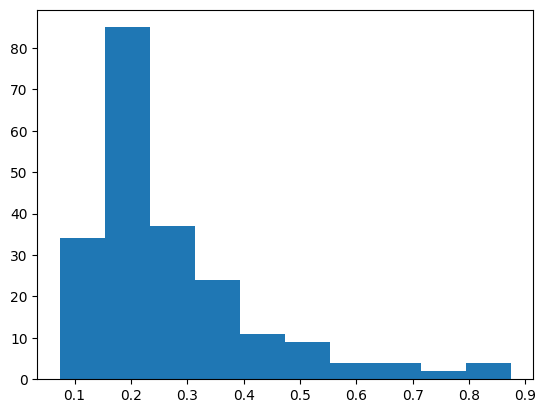

In [67]:
plt.hist(true_class_scores)

In [68]:
n = len(cal_compounds)
q_class = np.quantile(true_class_scores, math.ceil((n+1)*minimal_certainty)/n)

In [69]:
test_predictions = rfc.predict_proba(X_test)

In [ ]:
eval_classification_true_class(y_pred_proba=test_predictions, y_test=y_test.values.flatten(), sample_names=y_test.index, minimal_certainty=minimal_certainty, q = q_class, num_classes=2, class_names=[0,1])

TypeError: object of type 'numpy.float64' has no len()